# 4주차 ① 자동미분(Autograd) — 실습 1~4

**목표**: `requires_grad` 가 무엇을 켜는지 보고, `backward()` 가 채운 `.grad` 를 **손으로 검산**하며,
기울기가 **누적**된다는 성질과 `zero_grad()` 가 필요한 이유를 직접 재현한다.

| 실습 | 내용 | 셀 |
|---|---|---|
| 1 | `requires_grad` → `backward()` → `.grad` | 1~3 |
| 2 | 합성함수 연쇄 + `grad_fn` | 4~5 |
| 3 | **`zero_grad()` 누락 재현** | 6~9 |
| 4 | 학습률 3종 비교 | 10~12 |

> **실행 전 확인** — 우측 상단 커널 이름이 **`Python (dl2026)`** 인지 보세요.
> 아니면 커널명을 눌러 `Python (dl2026)` 을 선택하세요. (2주차 실습 8에서 다룬 그것입니다.)

> **오늘은 GPU가 없어도 전부 됩니다.** 파라미터가 2~3개라 CPU가 오히려 빠릅니다.

## 실습 1 — `requires_grad` → `backward()` → `.grad`

In [1]:
# 셀 1 — y = x² 의 미분
import torch

x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

print("y        :", y)
print("y.grad_fn:", y.grad_fn)

y.backward()                  # ← 역전파
print("x.grad   :", x.grad)   # dy/dx = 2x = 6

# → y        : tensor(9., grad_fn=<PowBackward0>)
# → x.grad   : tensor(6.)

y        : tensor(9., grad_fn=<PowBackward0>)
y.grad_fn: <PowBackward0 object at 0x0000024B4D1CABF0>
x.grad   : tensor(6.)


**손으로 검산** — `y = x²` 이므로 `dy/dx = 2x`. `x = 3` 이니 **6**.

`y` 출력에 값 `9.` 뿐 아니라 **`grad_fn=<PowBackward0>`** 이 함께 나오는 것에 주목하세요.
계산 그래프가 그려졌다는 증거입니다.

In [2]:
# 셀 2 — requires_grad 는 실수형에만 가능하다
xi = torch.tensor(3)              # dtype=int64
print("dtype :", xi.dtype)

try:
    xi.requires_grad = True
except RuntimeError as e:
    print("오류 발생 →", e)

xf = torch.tensor(3).float()      # ← 해결: 실수형으로
xf.requires_grad = True
print("해결 후:", xf.dtype, xf.requires_grad)

dtype : torch.int64
오류 발생 → only Tensors of floating point and complex dtype can require gradients
해결 후: torch.float32 True


3주차에 *"딥러닝의 기본 dtype 은 float32"* 라고 한 이유가 이것입니다.
**학습되는 값은 전부 미분 대상이고, 미분은 실수에서만 됩니다.**

In [3]:
# 셀 3 — .grad 는 leaf(내가 직접 만든 텐서)에만 채워진다
x = torch.tensor(3.0, requires_grad=True)
mid = x * 2          # 중간 결과 (leaf 가 아니다)
out = mid ** 2
out.backward()

print("x.grad   :", x.grad)      # 채워진다   (out = 4x², d/dx = 8x = 24)
print("mid.grad :", mid.grad)    # None + 경고

x.grad   : tensor(24.)
mid.grad : None


C:\Users\white\AppData\Local\Temp\ipykernel_17456\1350961204.py:8: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:493.)
  print("mid.grad :", mid.grad)    # None + 경고


## 실습 2 — 합성함수 연쇄 + `grad_fn` 들여다보기

In [5]:
# 셀 4 — 연쇄 미분
x = torch.tensor(2.0, requires_grad=True)

a = x * 3          # a = 3x
b = a + 1          # b = 3x + 1
y = b ** 2         # y = (3x + 1)²

print("a.grad_fn:", a.grad_fn)
print("b.grad_fn:", b.grad_fn)
print("y.grad_fn:", y.grad_fn)

y.backward()
print("x.grad   :", x.grad)

# 손검산: dy/dx = 2(3x+1)·3 = 6(3x+1) = 6 × 7 = 42
# 전개해서 미분: (3x+1)² = 9x² + 6x + 1 → 18x + 6 = 18×2 + 6 = 42


a.grad_fn: <MulBackward0 object at 0x0000024B4D70BB50>
b.grad_fn: <AddBackward0 object at 0x0000024B4D2189D0>
y.grad_fn: <PowBackward0 object at 0x0000024B4D170940>
x.grad   : tensor(42.)


In [6]:
# 셀 5 — 그래프의 뒷줄을 따라가 본다
print(y.grad_fn)
print(y.grad_fn.next_functions)
print(y.grad_fn.next_functions[0][0].next_functions)

# Pow → Add → Mul : 우리가 쓴 순서의 정반대로 이어져 있다

((<AddBackward0 object at 0x0000024B4D2189D0>, 0),)
((<MulBackward0 object at 0x0000024B4D70BB50>, 0), (None, 0))


## 실습 3 — `zero_grad()` 누락 재현 ★★

**이번 주차의 핵심.** 중간고사 출제 1순위입니다.

In [7]:
# 셀 6 — backward() 를 여러 번 부르면?
w = torch.tensor(1.0, requires_grad=True)

for step in range(5):
    loss = (w - 3) ** 2       # w 는 그대로 두고, 매번 같은 손실을 계산
    loss.backward()
    print(f"step {step} | w.grad = {w.grad.item():7.1f}")

step 0 | w.grad =    -4.0
step 1 | w.grad =    -8.0
step 2 | w.grad =   -12.0
step 3 | w.grad =   -16.0
step 4 | w.grad =   -20.0


**핵심 질문**: `w` 는 한 번도 바뀌지 않았고 손실 식도 똑같습니다. 그런데 왜 `.grad` 가 계속 커질까요?

손검산으로는 `d/dw (w-3)² = 2(w-3) = -4` — **매번 −4가 나와야 정상**입니다.

> **`backward()` 는 `.grad` 에 대입하지 않고 더합니다.**
> ```
> w.grad = 새 기울기      ✗  (이렇게 동작하지 않는다)
> w.grad += 새 기울기     ○  ← 실제 동작
> ```

In [8]:
# 셀 7 — 지워 주면 어떻게 되나
w = torch.tensor(1.0, requires_grad=True)

for step in range(5):
    loss = (w - 3) ** 2
    loss.backward()
    print(f"step {step} | w.grad = {w.grad.item():7.1f}")
    w.grad.zero_()            # ← 이 한 줄을 추가

step 0 | w.grad =    -4.0
step 1 | w.grad =    -4.0
step 2 | w.grad =    -4.0
step 3 | w.grad =    -4.0
step 4 | w.grad =    -4.0


In [9]:
# 셀 8 — zero_grad 를 빼고 학습하면 어떻게 되는가
torch.manual_seed(42)
x = torch.randn(100, 1)
y = 3 * x + 2 + 0.2 * torch.randn(100, 1)     # 정답: w=3, b=2

w = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 0.1

for epoch in range(15):
    pred = x * w + b
    loss = ((pred - y) ** 2).mean()
    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        # w.grad.zero_()      ← 일부러 뺐다
        # b.grad.zero_()

    print(f"epoch {epoch:2d} | loss = {loss.item():12.4f} | w = {w.item():8.3f}")

epoch  0 | loss =      13.4948 | w =    0.605
epoch  1 | loss =       8.5041 | w =    1.691
epoch  2 | loss =       2.4404 | w =    3.041
epoch  3 | loss =       0.0602 | w =    4.382
epoch  4 | loss =       3.2243 | w =    5.442
epoch  5 | loss =       9.4403 | w =    6.010
epoch  6 | loss =      13.8279 | w =    5.971
epoch  7 | loss =      12.9538 | w =    5.336
epoch  8 | loss =       7.5221 | w =    4.233
epoch  9 | loss =       1.8081 | w =    2.886
epoch 10 | loss =       0.2909 | w =    1.567
epoch 11 | loss =       4.1381 | w =    0.543
epoch 12 | loss =      10.3049 | w =    0.017
epoch 13 | loss =      13.9444 | w =    0.094
epoch 14 | loss =      12.2205 | w =    0.756


**결과 해석** — 손실이 **줄었다가 다시 커지기를 반복**하며 끝내 수렴하지 않습니다.

실제 출력(`lr=0.1`, 시드 42)을 보면:

```
epoch  0 | loss =      13.4948 | w =    0.605
epoch  1 | loss =       8.5041 | w =    1.691
epoch  2 | loss =       2.4404 | w =    3.041
epoch  3 | loss =       0.0602 | w =    4.382   ← 손실이 거의 0! 잘 되는 것처럼 보인다
epoch  4 | loss =       3.2243 | w =    5.442   ← 그런데 w 가 3 을 지나쳐 계속 간다
epoch  5 | loss =       9.4403 | w =    6.010
...
epoch 14 | loss =      12.2205 | w =    0.756   ← 제자리로 돌아왔다. 이 순환이 계속 반복된다
```

**epoch 3 에서 손실이 0.06 까지 떨어집니다.** 여기까지만 보면 학습이 아주 잘 되는 것 같습니다.
그런데 `w` 는 정답 3 을 지나쳐 4.4, 5.4, 6.0 으로 계속 갑니다.

과거에 쌓인 기울기가 **관성처럼 같은 방향으로 계속 밀기 때문**입니다.
epoch 2 에서 `w` 가 이미 3 을 지났는데도 쌓인 `w.grad` 는 여전히 −13.5("오른쪽으로 가라")라서 6 근처까지 갔다가,
그다음엔 반대 방향으로 똑같이 지나칩니다. **마찰 없는 그릇 속의 공**처럼 넘어갔다 되돌아오기를 반복합니다.

> **직접 확인해 보기**: 셀 8의 `print` 에 `w.grad.item()` 을 추가해 보세요.
> 누적된 기울기가 −6.0 → −10.9 → −13.5 로 커지다가, epoch 6 에 와서야 + 로 바뀝니다.

> **이게 더 무서운 이유**: `nan` 이 뜨면 뭔가 잘못됐다는 걸 바로 압니다.
> 그런데 이 경우는 **중간에 한 번 잘 되는 것처럼 보입니다.**
> epoch 3 에서 멈췄다면 "학습 성공"이라고 착각했을 겁니다.

In [10]:
# 셀 9 — 두 줄을 되살리면 정상
torch.manual_seed(42)
x = torch.randn(100, 1)
y = 3 * x + 2 + 0.2 * torch.randn(100, 1)

w = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 0.1

for epoch in range(15):
    pred = x * w + b
    loss = ((pred - y) ** 2).mean()
    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()          # ★ 되살렸다
        b.grad.zero_()

    print(f"epoch {epoch:2d} | loss = {loss.item():8.4f} | w = {w.item():6.3f} | b = {b.item():6.3f}")

epoch  0 | loss =  13.4948 | w =  0.605 | b =  0.437
epoch  1 | loss =   8.5041 | w =  1.087 | b =  0.780
epoch  2 | loss =   5.3652 | w =  1.472 | b =  1.048
epoch  3 | loss =   3.3904 | w =  1.779 | b =  1.258
epoch  4 | loss =   2.1475 | w =  2.025 | b =  1.423
epoch  5 | loss =   1.3650 | w =  2.221 | b =  1.551
epoch  6 | loss =   0.8722 | w =  2.377 | b =  1.652
epoch  7 | loss =   0.5617 | w =  2.502 | b =  1.730
epoch  8 | loss =   0.3660 | w =  2.602 | b =  1.792
epoch  9 | loss =   0.2426 | w =  2.682 | b =  1.840
epoch 10 | loss =   0.1647 | w =  2.746 | b =  1.877
epoch 11 | loss =   0.1156 | w =  2.797 | b =  1.906
epoch 12 | loss =   0.0846 | w =  2.838 | b =  1.929
epoch 13 | loss =   0.0650 | w =  2.871 | b =  1.946
epoch 14 | loss =   0.0526 | w =  2.897 | b =  1.960


손실이 꾸준히 줄고 `w` 는 3, `b` 는 2 쪽으로 다가갑니다. 우리가 데이터를 만들 때 넣은 정답입니다.

> **`with torch.no_grad():` 는 왜?**
> 이 블록 안의 연산은 **그래프에 기록하지 않겠다**는 뜻입니다.
> 파라미터 갱신은 학습의 일부가 아니라 우리가 손으로 하는 조작이므로 기록할 이유가 없습니다.
> 3교시에 `optimizer.step()` 이 이걸 대신합니다.

## 실습 4 — 학습률 3종 비교

In [15]:
# 셀 10 — 학습률 실험 준비
#%pip install matplotlib
import torch
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

torch.manual_seed(42)

# 1. torch.linspace(0, 10, 100)
# 0(시작점)부터 10(끝점)까지를 동일한 간격으로 나누어 총 100개의 점을 만듭니다.
# 결과: 길이가 100인 1차원 텐서가 생성됩니다.
# Shape: torch.Size([100])
# 예: [0.0000, 0.1010, 0.2020, ..., 10.0000]
# 2. .reshape(-1, 1)
# 1차원 텐서를 행과 열을 가진 2차원 행렬(열벡터)로 구조를 변경합니다.
x = torch.linspace(0, 10, 100).reshape(-1, 1)     # ★ 값이 0~10 으로 크다 (의도적)
y = 3 * x + torch.randn(100, 1)                   # 정답: w = 3

def train(lr, epochs=100):
    w = torch.zeros(1, requires_grad=True)
    losses = []
    for _ in range(epochs):
        loss = ((x * w - y) ** 2).mean()
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            w.grad.zero_()
        losses.append(loss.item())
    return w.item(), losses

  Using cached matplotlib-3.11.2-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp313-cp313-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.2-cp313-cp313-win_amd64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp313-cp313-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.65.0-cp313-cp313-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl (70 kB)
Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

In [16]:
# 셀 11 — 0.0001 / 0.01 / 1.0
for lr in [0.0001, 0.01, 1.0]:
    w_final, losses = train(lr)
    print(f"lr = {lr:<8} | 최종 w = {w_final:12.4f} | 최종 loss = {losses[-1]:12.4f}")

lr = 0.0001   | 최종 w =       1.4720 | 최종 loss =      81.0134
lr = 0.01     | 최종 w =       3.0074 | 최종 loss =       0.9649
lr = 1.0      | 최종 w =          nan | 최종 loss =          nan


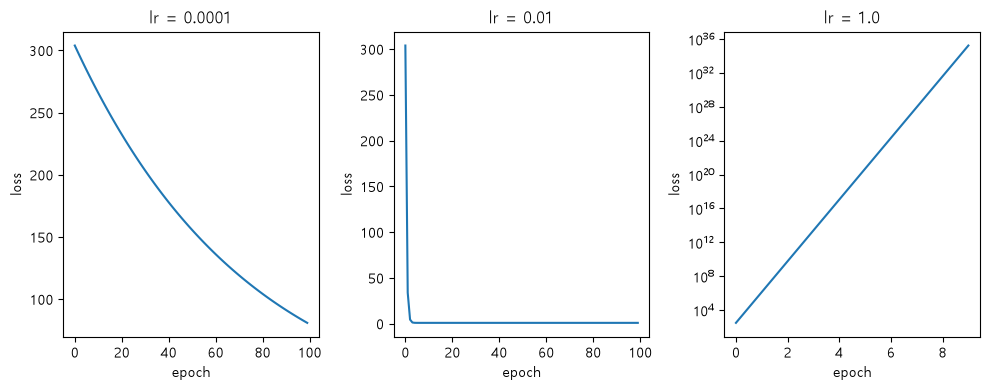

In [17]:
# 셀 12 — 곡선의 모양이 진단이다
plt.figure(figsize=(10, 4))
for i, lr in enumerate([0.0001, 0.01, 1.0], 1):
    _, losses = train(lr)
    plt.subplot(1, 3, i)
    plt.plot(losses)
    plt.title(f"lr = {lr}")
    plt.xlabel("epoch"); plt.ylabel("loss")
    if lr == 1.0:
        plt.yscale("log")          # 발산은 로그 축이라야 보인다
plt.tight_layout(); plt.show()

**세 그림의 모양을 눈에 새기세요.** 앞으로 학습이 이상할 때 가장 먼저 보게 될 것이 이 곡선입니다.


---

### 이 노트북 체크리스트

- [ ] 셀 1의 `x.grad = 6.` 을 손으로 검산했다
- [ ] 셀 4의 `x.grad = 42.` 를 손으로 검산했다
- [ ] 셀 6에서 `.grad` 가 −4, −8, −12… 로 **누적**되는 것을 봤다
- [ ] 셀 8에서 발산, 셀 9에서 수렴하는 것을 보고 **차이가 두 줄**임을 안다
- [ ] 셀 12의 세 곡선 모양으로 lr 이 큰지 작은지 말할 수 있다